In [1]:
import pandas as pd
import os
from pathlib import Path
import sklearn
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Subject 1.csv')

df = df.copy()
df['EventDateTime'] = pd.to_datetime(df['EventDateTime'])
# Convert CGM to numeric, coercing errors (handling non-numeric entries)
df['CGM'] = pd.to_numeric(df['CGM'], errors='coerce')
# Drop rows where CGM is now NaN
df.dropna(subset=['CGM'], inplace=True)

In [4]:
# --- START OF REVISED CODE BLOCK ---

# After initial data cleaning: df.dropna(subset=['CGM'], inplace=True)
# We need to filter out rows where NO event occurred, as those rows are useless for event clustering.

# Identify event columns. We use 'Correction', 'TotalBolus', and 'CarbSize'.
event_columns = ['CorrectionDelivered', 'TotalBolusInsulinDelivered', 'CarbSize']

# Fill NA in event columns with 0, as NaN here means "no event"
df[event_columns] = df[event_columns].fillna(0)

# Create a combined 'Event_Count' column:
# We'll use 1 if any event occurred, or simply use the TotalBolus amount as the feature.
# Using TotalBolus (insulin units) provides a better magnitude feature.
df['Intervention_Magnitude'] = df['TotalBolusInsulinDelivered'] + df['CarbSize']
# We'll use 1 if any event occurred, or simply use the TotalBolus amount as the feature.
# Using TotalBolus (insulin units) provides a better magnitude feature.
df['Intervention_Magnitude'] = df['TotalBolusInsulinDelivered'] + (df['CarbSize'] / 10) # Normalize CarbSize to a comparable magnitude (e.g., 10g carb ~ 1 unit insulin)

# Filter the DataFrame to include only rows where an event occurred
events_df = df[df['Intervention_Magnitude'] > 0].copy()

# Add Time Index columns (same as before, but critical here)
events_df['Date'] = events_df['EventDateTime'].dt.date
events_df['Hour'] = events_df['EventDateTime'].dt.hour
events_df['Minute'] = events_df['EventDateTime'].dt.minute
# TimeIndex for 24 hours (288 features)
events_df['TimeIndex'] = events_df['Hour'] * 60 + events_df['Minute']

# 2. Pivot the Data for Event Clustering
# Pivot the data to create a 24-hour profile of intervention magnitudes (counts/amounts)
# Each row = a day/subject, each column = a 5-minute time slot.
# We use sum() to aggregate multiple events that might fall into the same 5-minute window (though rare).
daily_profiles = events_df.pivot_table(
    index=['Date'],
    columns='TimeIndex',
    values='Intervention_Magnitude',
    fill_value=0, # Crucial: Fill all time slots where no event occurred with 0
    aggfunc='sum'
)

# K-means requires all samples (days) to have the same features (time slots).
# The pivot table will only include columns that had events. We need the full 24-hour range (0 to 1435).
# Create a MultiIndex for the full 24 hours (288 columns)
full_time_index = pd.Index(range(0, 1440, 5), name='TimeIndex')

# Reindex the daily_profiles to ensure all 288 columns exist, filling missing time slots with 0.
daily_profiles = daily_profiles.reindex(columns=full_time_index, fill_value=0)

# The daily_profiles DataFrame is now ready for scaling!
features = daily_profiles.values
print(f"Shape of daily_profiles (Event Magnitudes): {daily_profiles.shape}")
print(f"Shape of features: {features.shape}")

# --- END OF REVISED CODE BLOCK ---

Shape of daily_profiles (Event Magnitudes): (39, 288)
Shape of features: (39, 288)


In [ ]:
# VANA!
# ... (Previous code up to df.dropna(subset=['CGM'], inplace=True)) ...

# ----------------------------------------------------------------------
# REVISED FEATURE ENGINEERING: Focusing on 2-hour window around minimum CGM
# ----------------------------------------------------------------------

# 1. Identify the Lowest CGM Point of the Day
df['Date'] = df['EventDateTime'].dt.date

# Find the index of the minimum CGM reading for each Subject/Date
idx_min_cgm = df.groupby(['Date'])['CGM'].idxmin()

# Create a DataFrame containing only the lowest reading time/value for each day
min_cgm_points = df.loc[idx_min_cgm].reset_index(drop=True)

# 2. Extract the Windowed Profiles
window_profiles = []
window_size_minutes = 120 # 2 hours
interval_minutes = 5
expected_readings = int(window_size_minutes / interval_minutes) # 24 readings (12 before, the min, 11 after)

# Set the original DataFrame index to datetime for efficient slicing
df_indexed = df.set_index('EventDateTime')

for index, row in min_cgm_points.iterrows():
    min_time = row['EventDateTime']

    # Define the window start and end times: 60 minutes before and 55 minutes after the minimum (to include the min point)
    start_time = min_time - pd.Timedelta(minutes=60)
    end_time = min_time + pd.Timedelta(minutes=55)

    # Filter the original data for the specific subject and time window
    # Slicing the indexed DataFrame is fast
    window_data = df_indexed.loc[
        (df_indexed.index >= start_time) &
        (df_indexed.index <= end_time)
    ]

    # Check if the window is complete (exactly 24 readings)
    if len(window_data) == expected_readings:
        profile = window_data['CGM'].values.tolist()
        window_profiles.append({
            'Date': row['Date'],
            'Profile': profile
        })

# Convert the list of dictionaries into the final feature DataFrame
window_df = pd.DataFrame(window_profiles)

# Separate the profile list into 24 distinct feature columns
features_df = pd.DataFrame(window_df['Profile'].tolist(), index=window_df[['Date']])

# Rename columns to reflect the time relative to the minimum (T-60 up to T+55)
# This creates labels like 'T-60', 'T-55', ..., 'T-5', 'T0', 'T+5', ..., 'T+55'
time_labels = [f'T-{60 - i * 5}' for i in range(12)] + ['T0'] + [f'T+{i * 5}' for i in range(1, 12)]
features_df.columns = time_labels

# Now, features_df is the new daily_profiles DataFrame
daily_profiles = features_df

# Impute any remaining NaNs, although the check above should make this less necessary
# This imputation uses the mean of the 24 features across all samples (a basic fallback)
daily_profiles.fillna(daily_profiles.mean(), inplace=True)

features = daily_profiles.values # Get the array of profiles
print(f"Shape of daily_profiles (2-hour windows): {daily_profiles.shape}")
print(f"Shape of features: {features.shape}")
# ----------------------------------------------------------------------

# ... (Rest of the code continues with scaler = StandardScaler() ...)

Shape of daily_profiles (2-hour windows): (36, 24)
Shape of features: (36, 24)


In [5]:
df['TimeOfDay'] = df['EventDateTime'].dt.time
df['Hour'] = df['EventDateTime'].dt.hour
df['Minute'] = df['EventDateTime'].dt.minute
df['Date'] = df['EventDateTime'].dt.date
df['TimeIndex'] = df['Hour'] * 60 + df['Minute'] # Time in minutes from midnight

# Pivot the data
daily_profiles = df.pivot_table(
    index=['Date'],
    columns='TimeIndex',
    values='CGM'
)
daily_profiles = daily_profiles.T.fillna(daily_profiles.T.mean()).T
features = daily_profiles.values

print(f"Daily Profiles head:\n{daily_profiles.head()}")
print(f"Total sum of values in daily_profiles: {daily_profiles.sum().sum()}")
print(f"Number of NaN values in daily_profiles: {daily_profiles.isnull().sum().sum()}")


Daily Profiles head:
TimeIndex         4           9           14          19          24    \
Date                                                                     
2023-12-08  151.000000  152.000000  156.000000  158.000000  160.000000   
2023-12-09  115.000000  116.000000  116.000000  116.000000  117.000000   
2023-12-10  130.156863  130.156863  130.156863  130.156863  130.156863   
2023-12-11  151.000000  149.000000  148.000000  148.000000  148.000000   
2023-12-12  202.000000  203.000000  205.000000  207.000000  210.000000   

TimeIndex         29          34          39          44          49    ...  \
Date                                                                    ...   
2023-12-08  161.000000  161.000000  161.000000  160.000000  160.000000  ...   
2023-12-09  115.000000  116.000000  118.000000  119.000000  119.000000  ...   
2023-12-10  130.156863  130.156863  130.156863  130.156863  130.156863  ...   
2023-12-11  148.000000  146.000000  147.000000  148.000000  148.0

In [6]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print(f"Shape of scaled_features: {scaled_features.shape}")
print(f"Min value in scaled_features: {np.min(scaled_features)}")
print(f"Max value in scaled_features: {np.max(scaled_features)}")
print(f"Mean value in scaled_features: {np.mean(scaled_features)}")
print(f"Sum of scaled_features: {np.sum(scaled_features)}")
print(f"Number of NaNs in scaled_features: {np.sum(np.isnan(scaled_features))}")


Shape of scaled_features: (39, 288)
Min value in scaled_features: -2.6532967886544077
Max value in scaled_features: 3.6527642794458073
Mean value in scaled_features: 4.554761126667309e-17
Sum of scaled_features: 5.115907697472721e-13
Number of NaNs in scaled_features: 0


In [7]:
print(f"Number of unique rows in scaled_features: {np.unique(scaled_features, axis=0).shape[0]}")
inertia = []
k_range = range(2, 16)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

Number of unique rows in scaled_features: 39


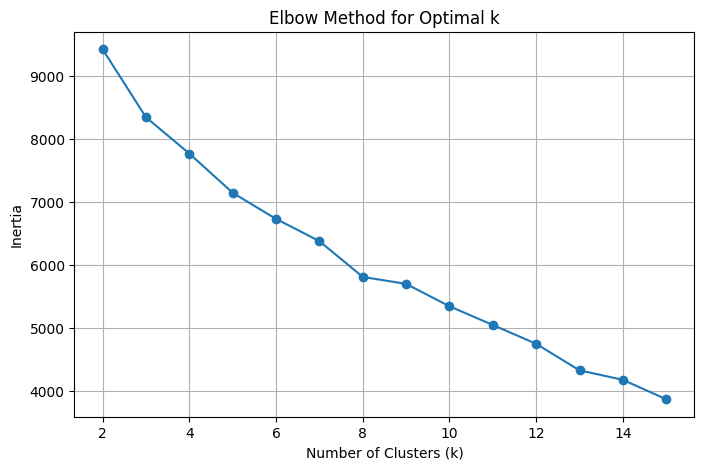

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [33]:
optimal_k = 2  # Based on the elbow plot
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(scaled_features)

In [34]:
daily_profiles['Cluster'] = cluster_labels
cluster_centers_scaled = final_kmeans.cluster_centers_

In [35]:
# Inverse transform the centers to original CGM units for plotting
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)

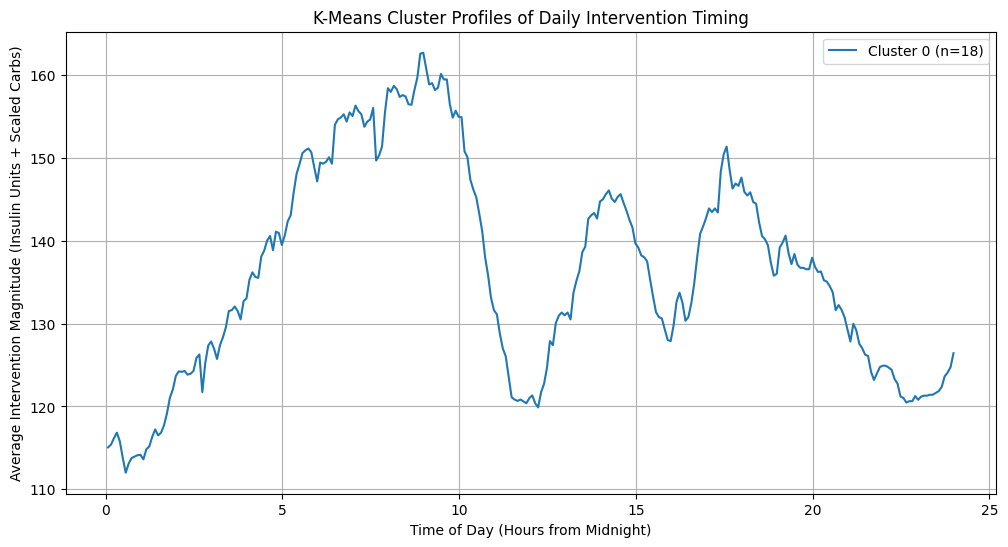

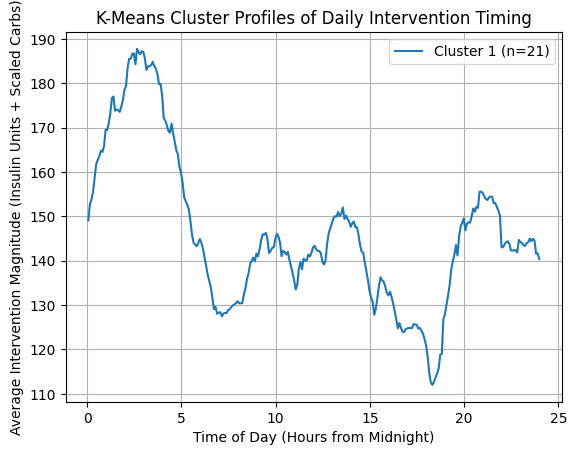

In [36]:
# ... (After the K-Means steps) ...

# Inverse transform the centers to original units for plotting (Intervention Magnitude)
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)

plt.figure(figsize=(12, 6))
# Exclude the 'Cluster' column when converting to int
time_points = daily_profiles.columns[:-1].astype(int) / 60 # Convert minutes to hours (0 to 24)

for i in range(optimal_k):
    # Cluster centers now represent the average intervention magnitude profile
    # Note: If cluster_centers are all zeros, check the data used for clustering.
    plt.plot(time_points, cluster_centers[i], label=f'Cluster {i} (n={np.sum(cluster_labels==i)})')

# --- REVISE PLOT TITLES HERE ---
    plt.title('K-Means Cluster Profiles of Daily Intervention Timing')
    plt.xlabel('Time of Day (Hours from Midnight)')
    plt.ylabel('Average Intervention Magnitude (Insulin Units + Scaled Carbs)') # Updated Y-label
    plt.legend()
    plt.grid(True)
    plt.show()

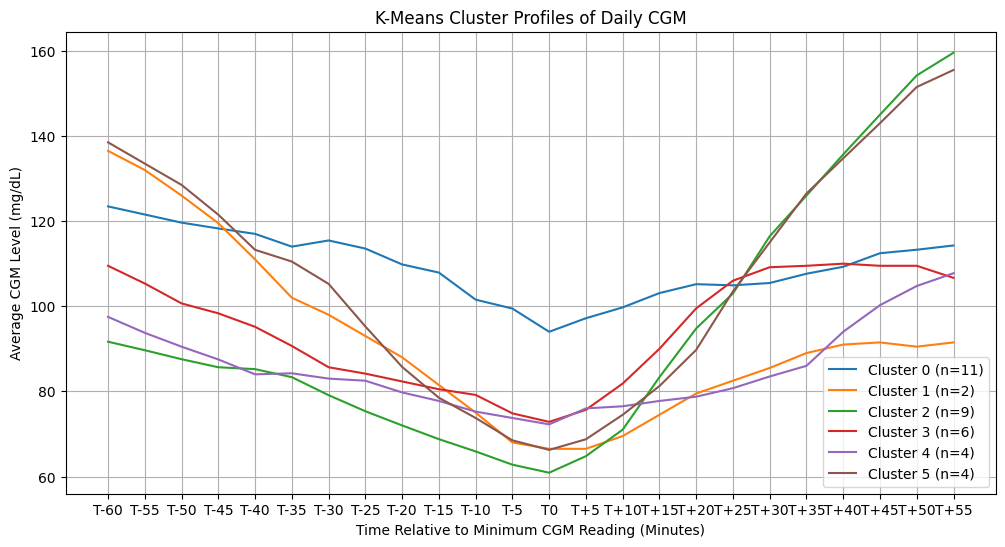

In [ ]:
# VANA!

plt.figure(figsize=(12, 6))
# Use the column names which are the relative time points in minutes
# Convert 'T-60', 'T0', 'T+55' labels to numeric time points for plotting
time_points_str = daily_profiles.columns[:-1] # Get all time labels (excluding 'Cluster')
time_points_minutes = [int(s.replace('T', '').replace('+', '')) for s in time_points_str]
time_points_minutes[12] = 0 # Ensure T0 is exactly 0
for i in range(optimal_k):
    plt.plot(time_points_str, cluster_centers[i], label=f'Cluster {i} (n={np.sum(cluster_labels==i)})')

plt.title('K-Means Cluster Profiles of Daily CGM')
plt.xlabel('Time Relative to Minimum CGM Reading (Minutes)')
plt.ylabel('Average CGM Level (mg/dL)')
plt.legend()
plt.grid(True)
plt.show()

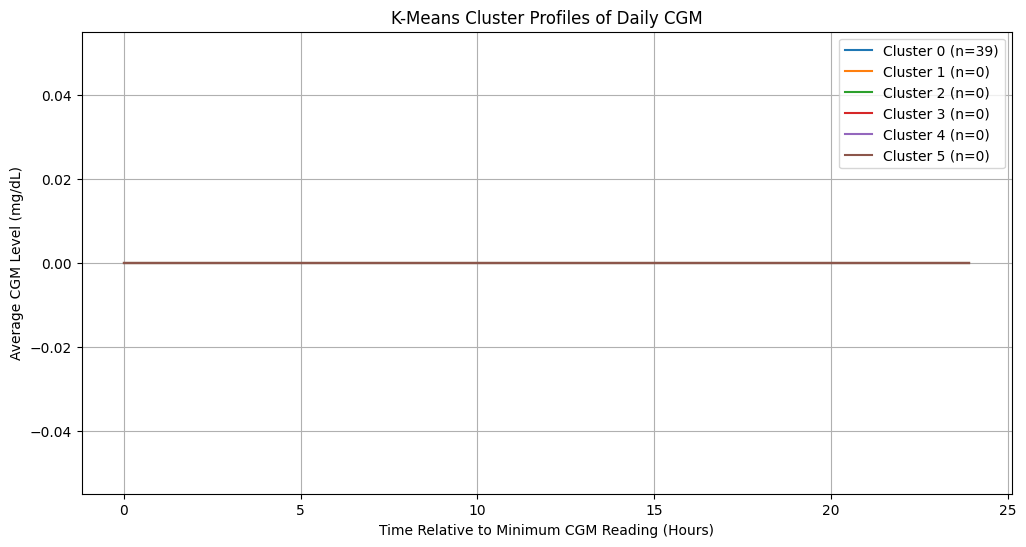

In [ ]:
plt.figure(figsize=(12, 6))
# Use the column names which are the relative time points in minutes
# Convert 'T-60', 'T0', 'T+55' labels to numeric time points for plotting
time_points_str = daily_profiles.columns[:-1] # Get all time labels (excluding 'Cluster')
time_points_minutes = []
for s in time_points_str:
    try:
        # Handle integer columns directly (e.g., from full daily profiles)
        time_points_minutes.append(int(s))
    except ValueError:
        # Handle string columns like 'T-60', 'T0', 'T+55'
        if s == 'T0':
            time_points_minutes.append(0)
        else:
            time_points_minutes.append(int(s.replace('T', '').replace('+', '')))

time_points = np.array(time_points_minutes) / 60.0 # Convert minutes to hours

for i in range(optimal_k):
    plt.plot(time_points, cluster_centers[i], label=f'Cluster {i} (n={np.sum(cluster_labels==i)})')

plt.title('K-Means Cluster Profiles of Daily CGM')
plt.xlabel('Time Relative to Minimum CGM Reading (Hours)')
plt.ylabel('Average CGM Level (mg/dL)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#reverse klaster ehk timeline ja klasterda vahemike järgi